In [115]:
import torch
from torch import nn, optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader
from datetime import datetime
import numpy as np
from torch.utils.data import Dataset
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn.functional as F
from collections import Counter


In [116]:
torch.manual_seed(42)
torch.set_default_dtype(torch.double)

In [117]:
device = (torch.device('cuda') if torch.cuda.is_available()
          else torch.device('cpu'))
print(f"Training on device {device}.")

Training on device cpu.


In [118]:
CLASS_COLOURS = ['skyblue', 'pink']

In [119]:
def show_img(img, label) -> None:
    img = img.squeeze().permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(f"Label: {label}")
    plt.axis('off')
    plt.show()

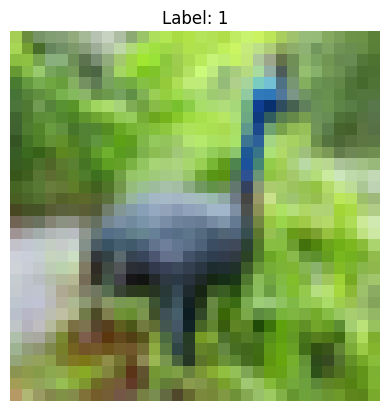

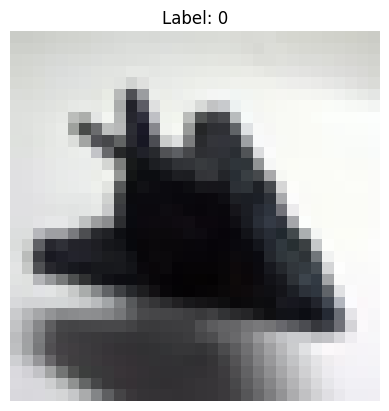

In [ ]:
class CIFAR2(Dataset):
    def __init__(self, data_path: Path):
        self.data_path = data_path
        self.data, self.targets = self.__loaddata__()

        self.transformer = transforms.Compose([
            transforms.ToTensor(),
        ])
    
    def __loaddata__(self):
        data = datasets.CIFAR10(
            root=str(self.data_path),
            transform=None,
            download=True
        )
        targets = np.array(data.targets)
        indices = (targets == 0) | (targets == 2) # plane, bird

        images, targets = data.data[indices], targets[indices]

        # resample 0 is ok, 2 -> 1
        targets = [1 if t == 2 else t for t in targets]

        return images, targets

    def __getitem__(self, idx) -> tuple[torch.Tensor, int]:
        img, target = self.data[idx], self.targets[idx]        
        return self.transformer(img), target

    def __len__(self):
        return len(self.data)

cifar = CIFAR2("data/")
img, label = cifar[0]
show_img(img, label) # bird = 1
img, label = cifar[4]
show_img(img, label) # plane = 0

In [ ]:
class Preprocessor():
    """wip"""
    def __init__(self):
        ...
        self.transformer = transforms.Compose([
            # TODO: is this the correct normalization for CIFAR10?
            # transforms.Normalize((0.4915, 0.4823, 0.4468),
            #                      (0.2470, 0.2435, 0.2616))
            
        ])

In [ ]:
def load_cifar(train_val_split=0.9, data_path='data/', preprocessor=None):
    cifar2 = CIFAR2(Path(data_path))

    train_size = int(len(cifar2) * train_val_split)
    val_test_size = len(cifar2) - train_size

    cifar_generator = torch.Generator().manual_seed(42)
    train, val_test = random_split(cifar2, lengths=[train_size, val_test_size], generator=cifar_generator)
    
    test_val_split = 0.5 # 0.05, 0.05
    val_size = int(len(val_test) * test_val_split)
    test_size = len(val_test) - val_size
    
    val, test = random_split(val_test, lengths=[val_size, test_size], generator=cifar_generator)    

    batch_size = 32
    train_loader = DataLoader(train, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

train_loader,val_loader,test_loader = load_cifar()

def binary_to_label(targets):
    all_targets = ["plane" if t == 0 else t for t in targets]
    return ["bird" if t == 1 else t for t in all_targets ]

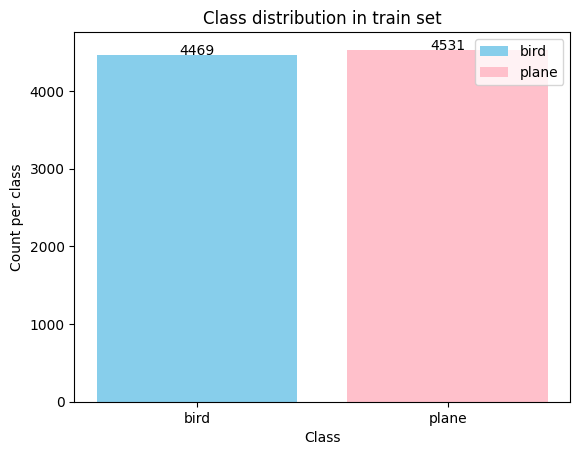

In [122]:
all_targets = torch.cat([label for _, label in train_loader]).tolist()
all_targets = binary_to_label(all_targets)

counts = Counter(all_targets)
plt.bar(list(counts.keys()), list(counts.values()), label=counts.keys(), color = CLASS_COLOURS)
plt.xlabel("Class")
plt.ylabel("Count per class")
plt.title("Class distribution in train set")
for x, y in counts.items():
    plt.text(x, y, f"{y}", ha='center')
plt.legend()
plt.show()

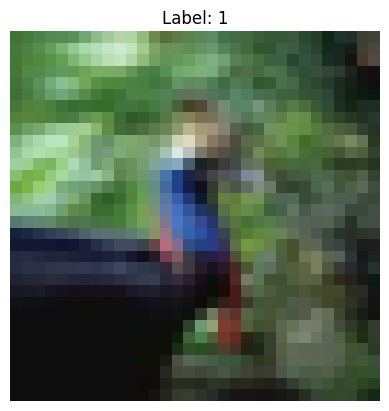

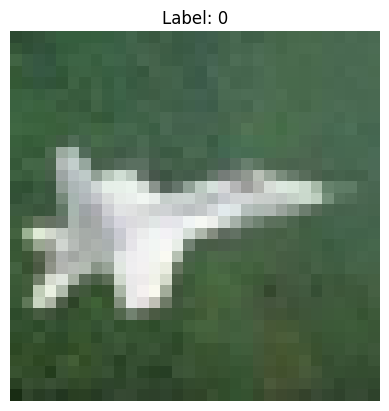

In [127]:
# TODO: variance in pixel colours
img, label = cifar[15]
show_img(img, label) # bird = 1
img, label = cifar[16]
show_img(img, label) # plane = 0


In [124]:
# TODO: simple masking

# evaluation

In [ ]:
# TODO, epoch validation loss over time.

In [ ]:
# TODO: confusion matrix 